# InSIGHT — AI 이미지 탐지 모델 벤치마크 리포트

**작성자:** woochul  
**실험 일시:** 2026-04-26  
**데이터셋:** AI 생성 이미지 101장 / 실제 인물 사진 249장 (총 350장)  
**평가 지표:** Accuracy / Precision / Recall / F1 / FPR / Inference Time

---

### 목표치
| 지표 | 목표 |
|---|---|
| Accuracy | 70% 이상 |
| Precision | 75% 이상 |
| Recall ★ | 75% 이상 (핵심) |
| F1 Score | 70% 이상 |
| FPR | 20% 이하 |
| Inference Time | 3.0초 이하 |
---

### 테스트 데이터셋

> 이미지 데이터는 Google Drive에서 관리합니다.  
> 로컬 실행 전 아래 링크에서 `test_dataset/` 폴더를 다운로드 후 프로젝트 루트에 배치하세요.

**Google Drive:** https://drive.google.com/drive/folders/11Hu7vRj2f-l6ottcFQLy68xRHLheUs4w

| 폴더 | 내용 | 출처 |
|---|---|---|
| `test_dataset/ai/` | AI 생성 인물 이미지 | Civitai API (Flux, SDXL 최신 모델) |
| `test_dataset/real/` | 실제 인물 사진 | randomuser.me / Unsplash |

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# ── 색상 팔레트 ──────────────────────────────────────────────
COLOR_PASS   = '#2ecc71'   # 목표 달성
COLOR_FAIL   = '#e74c3c'   # 목표 미달
COLOR_TOP    = '#3498db'   # TOP 모델 강조
COLOR_TARGET = '#f39c12'   # 목표선

print('Libraries loaded.')

Libraries loaded.


In [2]:
# ── 데이터 로드 ──────────────────────────────────────────────
import os
csv_path = os.path.join(os.path.dirname(os.path.abspath('__file__')), 
                        'benchmark_results_20260426_184945.csv')
df = pd.read_csv(csv_path)

# 모델명 단축
df['short_name'] = df['model'].apply(lambda x: x.split('/')[-1])

# 목표치
TARGET = {
    'accuracy' : 70.0,
    'precision': 75.0,
    'recall'   : 75.0,
    'f1'       : 70.0,
    'fpr'      : 20.0,
    'avg_time' : 3.0,
}

# TOP 모델
TOP_MODEL = 'ai-image-detector-deploy'

df

,model,accuracy,precision,recall,f1,fpr,avg_time,tp,fp,fn,tn,n_total,n_failed,short_name
0,umm-maybe/AI-image-detector,26.36,5.68,9.90,7.22,66.94,0.566,10,166,91,82,349,1,AI-image-detector
1,Organika/sdxl-detector,77.08,59.13,67.33,62.96,18.95,0.449,68,47,33,201,349,1,sdxl-detector
2,haywoodsloan/ai-image-detector-deploy,88.25,75.86,87.13,81.11,11.29,0.828,88,28,13,220,349,1,ai-image-detector-deploy
3,prithivMLmods/Deep-Fake-Detector-Model,30.66,17.81,38.61,24.38,72.58,0.257,39,180,62,68,349,1,Deep-Fake-Detector-Model


## 1. 핵심 지표 비교 (막대 그래프)

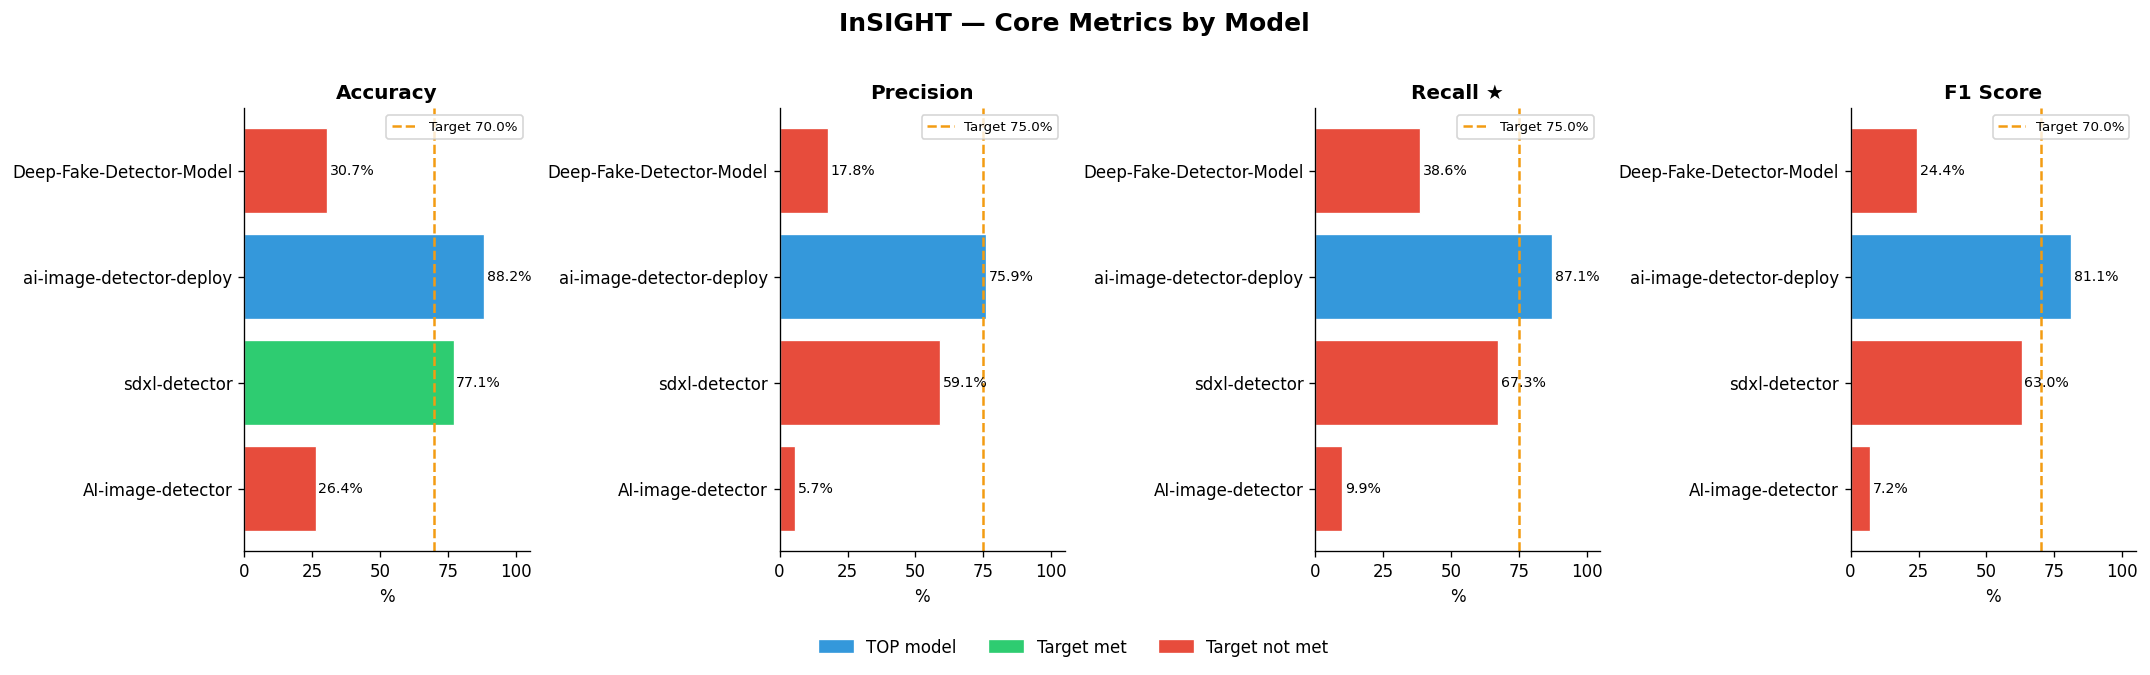

Saved: benchmark_core_metrics.png


In [3]:
metrics     = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall ★', 'F1 Score']
targets     = [TARGET[m] for m in metrics]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('InSIGHT — Core Metrics by Model', fontsize=15, fontweight='bold', y=1.02)

for ax, metric, label, target in zip(axes, metrics, metric_labels, targets):
    values = df[metric].values
    names  = df['short_name'].values

    colors = []
    for name, val in zip(names, values):
        if name == TOP_MODEL:
            colors.append(COLOR_TOP)
        elif val >= target:
            colors.append(COLOR_PASS)
        else:
            colors.append(COLOR_FAIL)

    bars = ax.barh(names, values, color=colors, edgecolor='white', linewidth=0.8)
    ax.axvline(target, color=COLOR_TARGET, linestyle='--', linewidth=1.5, label=f'Target {target}%')
    ax.set_xlim(0, 105)
    ax.set_xlabel('%')
    ax.set_title(label, fontweight='bold')
    ax.legend(fontsize=8)

    for bar, val in zip(bars, values):
        ax.text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=8.5)

# 범례
legend_handles = [
    mpatches.Patch(color=COLOR_TOP,  label='TOP model'),
    mpatches.Patch(color=COLOR_PASS, label='Target met'),
    mpatches.Patch(color=COLOR_FAIL, label='Target not met'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.08), frameon=False)

plt.tight_layout()
plt.savefig('benchmark_core_metrics.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_core_metrics.png')

## 2. FPR & Inference Time

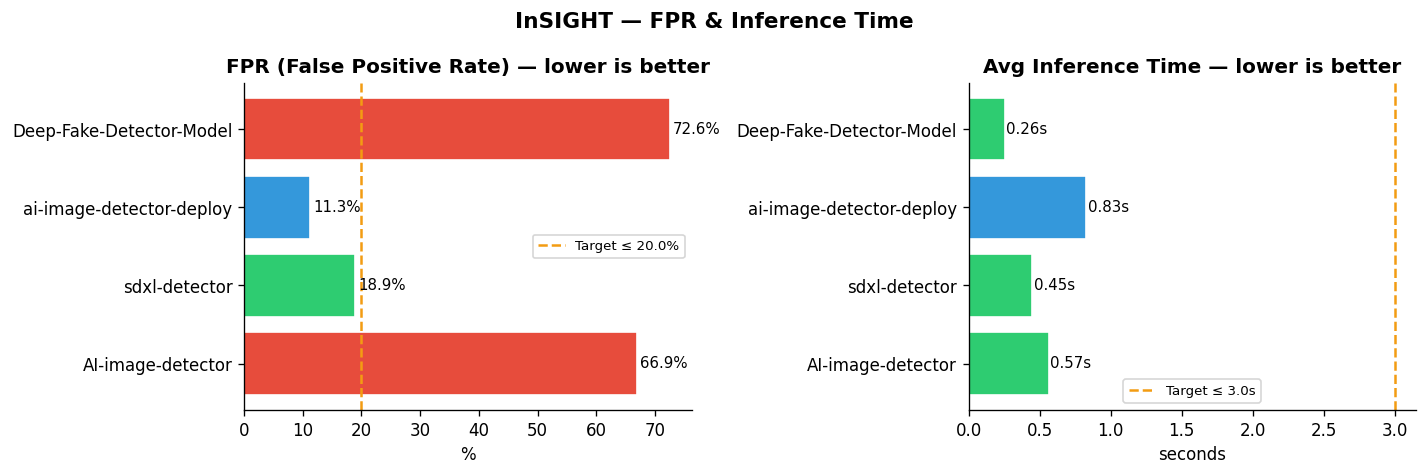

Saved: benchmark_fpr_time.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('InSIGHT — FPR & Inference Time', fontsize=13, fontweight='bold')

# FPR (낮을수록 좋음)
ax = axes[0]
fpr_colors = []
for name, val in zip(df['short_name'], df['fpr']):
    if name == TOP_MODEL:
        fpr_colors.append(COLOR_TOP)
    elif val <= TARGET['fpr']:
        fpr_colors.append(COLOR_PASS)
    else:
        fpr_colors.append(COLOR_FAIL)

bars = ax.barh(df['short_name'], df['fpr'], color=fpr_colors, edgecolor='white')
ax.axvline(TARGET['fpr'], color=COLOR_TARGET, linestyle='--', linewidth=1.5,
           label=f'Target ≤ {TARGET["fpr"]}%')
ax.set_xlabel('%')
ax.set_title('FPR (False Positive Rate) — lower is better', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars, df['fpr']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

# Inference Time
ax = axes[1]
time_colors = []
for name, val in zip(df['short_name'], df['avg_time']):
    if name == TOP_MODEL:
        time_colors.append(COLOR_TOP)
    elif val <= TARGET['avg_time']:
        time_colors.append(COLOR_PASS)
    else:
        time_colors.append(COLOR_FAIL)

bars = ax.barh(df['short_name'], df['avg_time'], color=time_colors, edgecolor='white')
ax.axvline(TARGET['avg_time'], color=COLOR_TARGET, linestyle='--', linewidth=1.5,
           label=f'Target ≤ {TARGET["avg_time"]}s')
ax.set_xlabel('seconds')
ax.set_title('Avg Inference Time — lower is better', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars, df['avg_time']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('benchmark_fpr_time.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_fpr_time.png')

## 3. 레이더 차트 (종합 성능 비교)

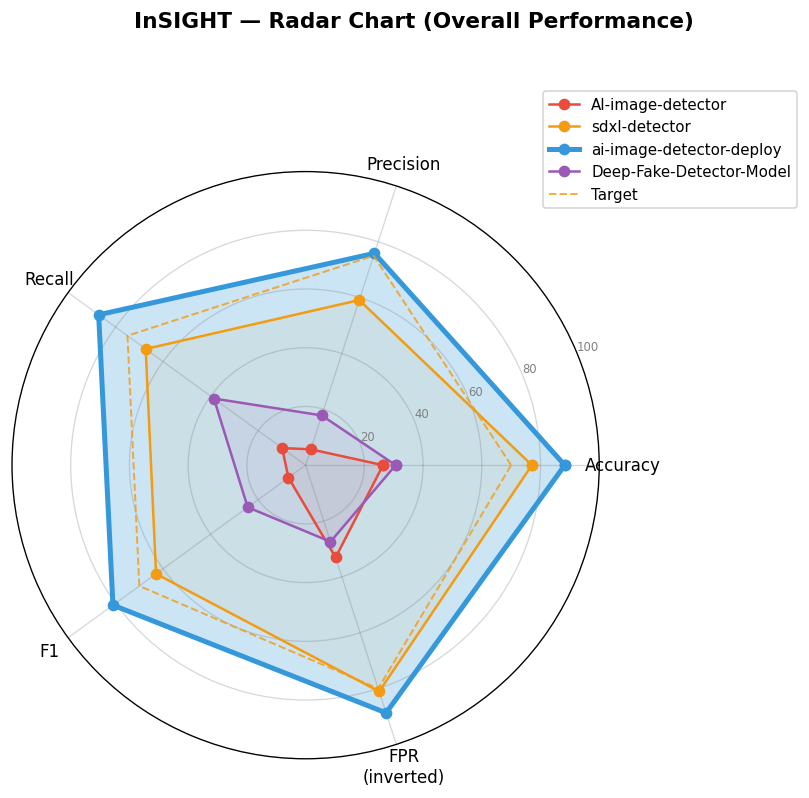

Saved: benchmark_radar.png


In [5]:
from matplotlib.patches import FancyBboxPatch

# FPR은 반전 (낮을수록 좋으니까 100-FPR로 변환)
radar_metrics = ['accuracy', 'precision', 'recall', 'f1', 'fpr_inv']
radar_labels  = ['Accuracy', 'Precision', 'Recall', 'F1', 'FPR\n(inverted)']

df['fpr_inv'] = 100 - df['fpr']

angles = np.linspace(0, 2 * np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]  # 닫기

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('InSIGHT — Radar Chart (Overall Performance)', fontsize=13, fontweight='bold')

model_colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']

for i, row in df.iterrows():
    values = [row[m] for m in radar_metrics]
    values += values[:1]
    lw   = 3 if row['short_name'] == TOP_MODEL else 1.5
    alpha = 0.25 if row['short_name'] == TOP_MODEL else 0.08
    ax.plot(angles, values, 'o-', linewidth=lw,
            color=model_colors[i], label=row['short_name'])
    ax.fill(angles, values, alpha=alpha, color=model_colors[i])

# 목표선
target_vals = [70, 75, 75, 70, 80]  # fpr_inv = 100-20 = 80
target_vals += target_vals[:1]
ax.plot(angles, target_vals, '--', linewidth=1.2,
        color=COLOR_TARGET, label='Target', alpha=0.8)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=7, color='grey')
ax.grid(color='grey', alpha=0.3)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)

plt.tight_layout()
plt.savefig('benchmark_radar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_radar.png')

## 4. 혼동 행렬 (Confusion Matrix)

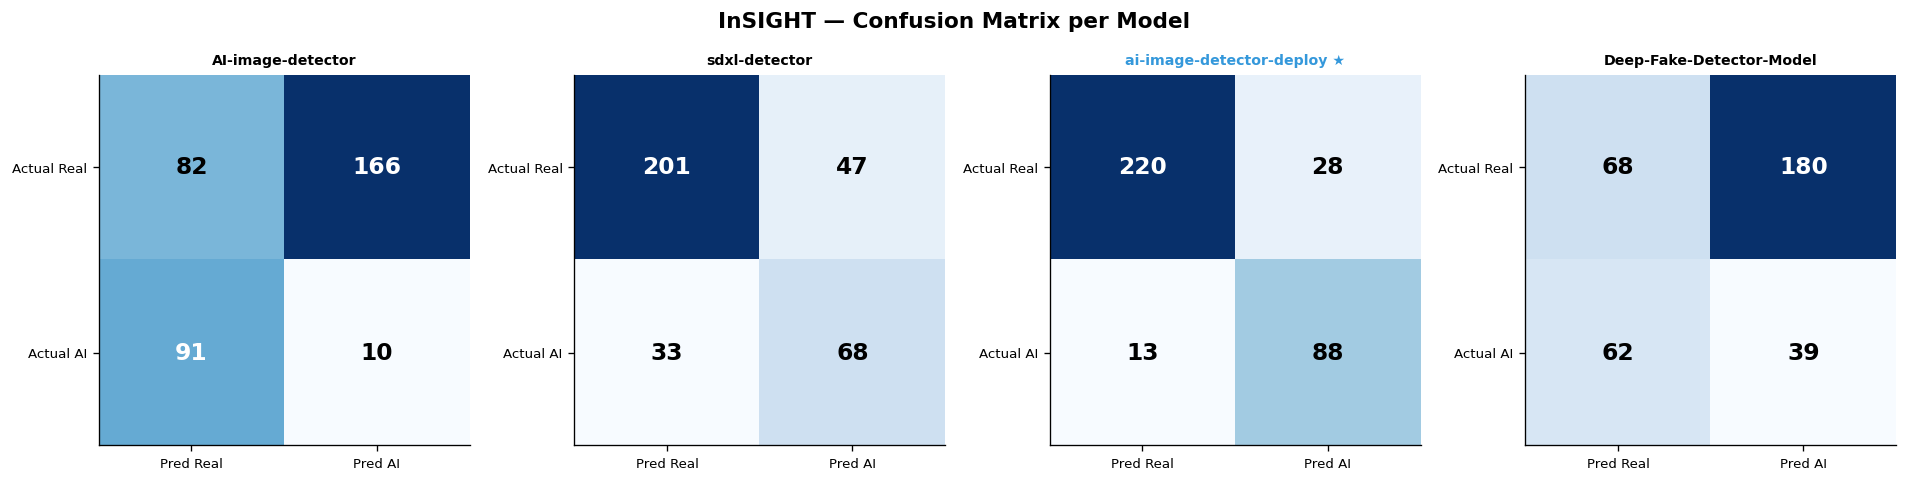

Saved: benchmark_confusion.png


In [6]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16, 4))
fig.suptitle('InSIGHT — Confusion Matrix per Model', fontsize=13, fontweight='bold')

for i, (_, row) in enumerate(df.iterrows()):
    ax = fig.add_subplot(1, len(df), i + 1)
    cm = np.array([[row['tn'], row['fp']],
                   [row['fn'], row['tp']]])

    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Pred Real', 'Pred AI'], fontsize=8)
    ax.set_yticklabels(['Actual Real', 'Actual AI'], fontsize=8)

    for r in range(2):
        for c in range(2):
            ax.text(c, r, int(cm[r, c]),
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r, c] > cm.max() / 2 else 'black')

    title_color = COLOR_TOP if row['short_name'] == TOP_MODEL else 'black'
    star = ' ★' if row['short_name'] == TOP_MODEL else ''
    ax.set_title(f"{row['short_name']}{star}", fontsize=8.5,
                 fontweight='bold', color=title_color)

plt.tight_layout()
plt.savefig('benchmark_confusion.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_confusion.png')

## 5. 목표 달성 현황표

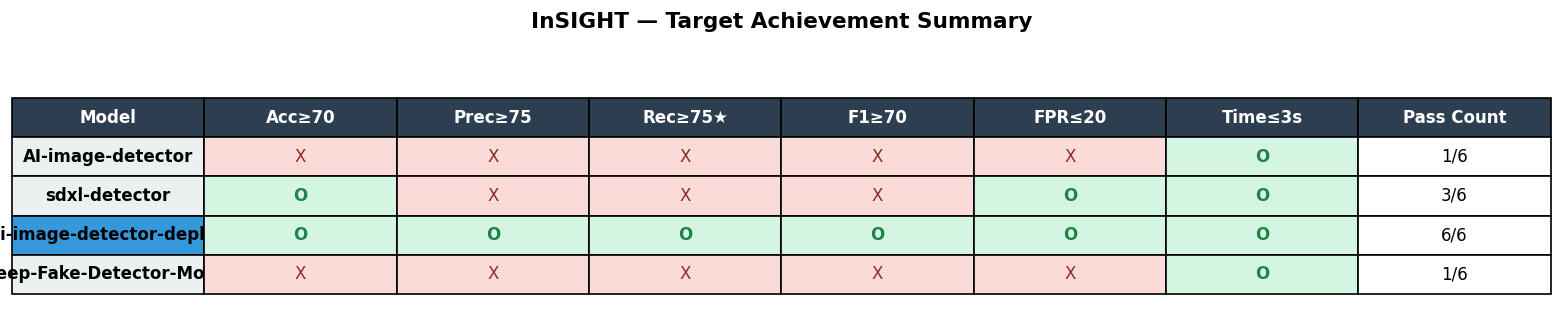

Saved: benchmark_summary_table.png


In [7]:
check_metrics = {
    'accuracy' : (TARGET['accuracy'],  False),
    'precision': (TARGET['precision'], False),
    'recall'   : (TARGET['recall'],    False),
    'f1'       : (TARGET['f1'],        False),
    'fpr'      : (TARGET['fpr'],       True),   # lower is better
    'avg_time' : (TARGET['avg_time'],  True),
}

col_labels = ['Model', 'Acc≥70', 'Prec≥75', 'Rec≥75★', 'F1≥70', 'FPR≤20', 'Time≤3s', 'Pass Count']
table_data = []

for _, row in df.iterrows():
    r = [row['short_name']]
    pass_count = 0
    for metric, (tgt, lower) in check_metrics.items():
        ok = row[metric] <= tgt if lower else row[metric] >= tgt
        r.append('O' if ok else 'X')
        if ok:
            pass_count += 1
    r.append(f'{pass_count}/6')
    table_data.append(r)

fig, ax = plt.subplots(figsize=(13, 2.5))
ax.axis('off')

tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.0)

# 셀 색상
for (row_idx, col_idx), cell in tbl.get_celld().items():
    if row_idx == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col_idx == 0:
        name = table_data[row_idx - 1][0]
        cell.set_facecolor('#3498db' if name == TOP_MODEL else '#ecf0f1')
        cell.set_text_props(fontweight='bold')
    else:
        txt = cell.get_text().get_text()
        if txt == 'O':
            cell.set_facecolor('#d5f5e3')
            cell.set_text_props(color='#1e8449', fontweight='bold')
        elif txt == 'X':
            cell.set_facecolor('#fadbd8')
            cell.set_text_props(color='#922b21')

fig.suptitle('InSIGHT — Target Achievement Summary', fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('benchmark_summary_table.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_summary_table.png')

---
## 6. 결론 및 다음 단계 건의

### 현재 실험 결과 요약

| 순위 | 모델 | Recall | F1 | 전체 목표 달성 |
|---|---|---|---|---|
| **1위** ★ | `haywoodsloan/ai-image-detector-deploy` | **87.1%** | **81.1%** | **6/6** |
| 2위 | `Organika/sdxl-detector` | 67.3% | 63.0% | 2/6 |
| 3위 | `prithivMLmods/Deep-Fake-Detector-Model` | 38.6% | 24.4% | 1/6 |
| 4위 | `umm-maybe/AI-image-detector` (기존) | 9.9% | 7.2% | 1/6 |

**→ `haywoodsloan/ai-image-detector-deploy`가 현재 시점 가장 유력한 모델**

---

### 추가 실험 건의 (아직 미측정 모델)

아래 모델들도 같은 기준으로 베이스라인 성능 지표를 뽑아볼 것을 건의합니다.

| 모델 | 특징 | 우선순위 |
|---|---|---|
| `Heem2/Real-or-Fake-Image-Detection` | Real/Fake 직접 이진 분류 | 높음 |
| `saltacc/anime-real-classifier` | 애니/실사 구분 특화 | 높음 |
| `microsoft/resnet-50` + fine-tune | 범용 백본, 미세조정 가능 | 중간 |
| `google/vit-base-patch16-224` + fine-tune | ViT 기반, 직접 학습 | 중간 |
| `PAdiffusion/PAmachine` | Stable Diffusion 특화 탐지 | 낮음 |

### 실험 조건 통일 제안
- 데이터셋: 현재와 동일 (AI 101장 / Real 249장)
- 임계값: 0.5 고정
- 평가 지표: 6가지 동일 적용
- CSV 누적 기록으로 이력 관리

---
*본 노트북은 woochul ver. InSIGHT 프로젝트 벤치마크 리포트입니다.*

In [8]:
# 추가 실험 후보 모델 목록 (benchmark_runner.py MODELS 리스트에 추가할 것)
next_models = [
    'Heem2/Real-or-Fake-Image-Detection',
    'saltacc/anime-real-classifier',
    'PAdiffusion/PAmachine',
]

print('=== Next Benchmark Candidate Models ===')
for m in next_models:
    print(f'  {m}')
print()
print('Add these to MODELS list in benchmark_runner.py and re-run.')

=== Next Benchmark Candidate Models ===
  Heem2/Real-or-Fake-Image-Detection
  saltacc/anime-real-classifier
  PAdiffusion/PAmachine

Add these to MODELS list in benchmark_runner.py and re-run.


---
## 7. 탐지율 80% 달성 전략

### 현재 상태 진단

| | 현재 (ai-image-detector-deploy) | 신규 목표 |
|---|---|---|
| Accuracy | 88.2% | 80%+ 안정 유지 |
| Recall   | 87.1% | 80%+ 안정 유지 |
| F1       | 81.1% | 80%+ 안정 유지 |
| FPR      | 11.3% | 20%  이하 유지 |

> **핵심 과제:** 현재 수치는 101장 소규모 테스트 기준.  
> 실제 서비스에서 **최신 AI 모델(Flux, SD3.5, MJ v7 등)** 이미지에도  
> 동일하게 80% 이상을 안정적으로 유지하는 것이 진짜 목표.

---

### 전략 선택 기준

```
즉시 적용 가능         -> 전략 A: Threshold 튜닝
데이터로 성능 향상     -> 전략 B: 데이터 보강
여러 모델 결합         -> 전략 C: 앙상블
근본적 성능 향상       -> 전략 D: 파인튜닝
```

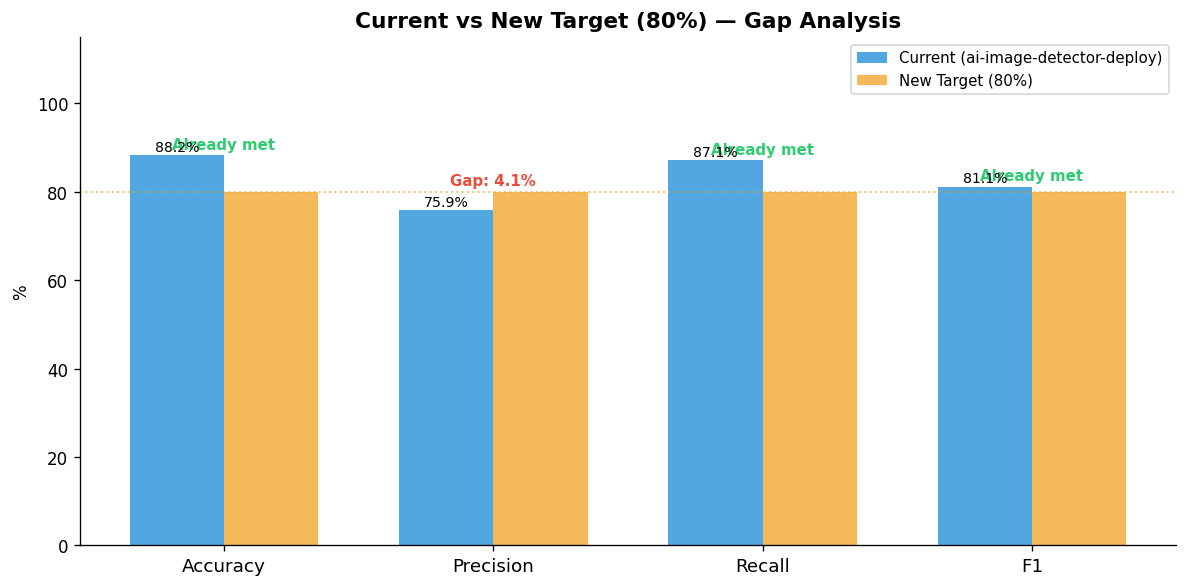

Saved: benchmark_gap_analysis.png


In [9]:
# 현재 성능 vs 목표 80% 갭 분석
top = df[df['short_name'] == TOP_MODEL].iloc[0]

metrics_gap = ['accuracy', 'precision', 'recall', 'f1']
labels_gap  = ['Accuracy', 'Precision', 'Recall', 'F1']
cur_vals = [top[m] for m in metrics_gap]
tgt_vals = [80.0] * 4

x = np.arange(len(labels_gap))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, cur_vals, w, label='Current (ai-image-detector-deploy)',
            color=COLOR_TOP, alpha=0.85)
b2 = ax.bar(x + w/2, tgt_vals, w, label='New Target (80%)',
            color=COLOR_TARGET, alpha=0.7)

for i, (c, t) in enumerate(zip(cur_vals, tgt_vals)):
    gap   = max(0, t - c)
    color = COLOR_PASS if gap == 0 else COLOR_FAIL
    mark  = 'Already met' if gap == 0 else f'Gap: {gap:.1f}%'
    ax.text(i, max(c, t) + 1.5, mark, ha='center',
            fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels_gap, fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('%')
ax.axhline(80, color=COLOR_TARGET, linestyle=':', linewidth=1.2, alpha=0.6)
ax.set_title('Current vs New Target (80%) — Gap Analysis',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8.5)

plt.tight_layout()
plt.savefig('benchmark_gap_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_gap_analysis.png')

---
### 전략 A. Threshold 튜닝 (학습 불필요, 즉시 적용)

> 현재 임계값=0.5 고정 -> 최적값이 아닐 수 있음.  
> 0.3~0.7 구간을 스윕해 **Recall 80%+ / FPR 20%-** 되는 지점 탐색

```python
for threshold in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred   = (ai_scores >= threshold).astype(int)
    recall = recall_score(y_true, pred)
    fpr    = fp / (fp + tn)
    # Recall 높이면서 FPR 20% 이하 유지하는 지점 탐색
```

**기대 효과:** Recall 87% -> 90%+ (FPR 소폭 증가 감수)  
**소요 시간:** 1~2시간 (코드 수정 + 재측정)

---
### 전략 B. 데이터 보강 (학습 불필요, 즉시 적용)

> 현재 AI 이미지 101장은 신뢰도 확보에 부족. 다양한 최신 모델 이미지 추가 필요.

#### 추가 수집 우선순위

| 대상 | 이유 | 소스 | 목표 수량 |
|---|---|---|---|
| **Flux.1 Dev/Schnell** | 2024~2025 최신, 가장 사실적 | Civitai API | 300장+ |
| **Midjourney v6/v7** | SNS 유통 압도적 1위 | r/midjourney | 200장+ |
| **SD 3.5 / SDXL** | 국내 커뮤니티 주류 | Civitai API | 200장+ |
| **탐지 회피 이미지** | LoRA + upscale 적용본 | Civitai (후기) | 100장+ |
| **Real 다양성 확보** | 현재 randomuser 편향 | FFHQ, CelebA | 500장+ |

**목표:** AI 800장+ / Real 800장+ 균형 데이터셋 구성  
**기대 효과:** 측정 신뢰도 향상, 실제 서비스 성능 80%+ 안정화

---
### 전략 C. 앙상블 (학습 불필요, 구현 1~2일)

> 단일 모델 한계를 복수 모델 조합으로 극복

현재 결과 기준 `ai-image-detector-deploy` + `sdxl-detector` 조합이 가장 유망

```python
# 소프트 보팅 (가중 평균)
score_deploy = detector_deploy(image)  # Recall 87%, 정확도 높음
score_sdxl   = detector_sdxl(image)    # SDXL 특화, FPR 낮음

ensemble = 0.7 * score_deploy + 0.3 * score_sdxl
is_ai    = ensemble >= 0.5
```

**기대 효과:** FN(미탐) 감소 -> Recall 90%+ 가능  
**단점:** 추론 시간 1.3배 증가 (0.83s -> ~1.1s, 목표치 이내)

---
### 전략 D. 파인튜닝 (학습 필요, GPU 기준 4~8시간)

> `ai-image-detector-deploy`를 베이스로 우리 데이터셋에 맞게 추가 학습  
> Phase 1~2로 한계에 도달했을 때 검토

#### 파인튜닝용 핵심 데이터셋
| 데이터셋 | 규모 | 특징 |
|---|---|---|
| `haywoodsloan/ai-images-2024` | ~50k | 2024년 생성 AI, HuggingFace |
| `elsaEU/ELSA_D3` | ~10k | 탐지 회피 이미지 포함 |
| `FFHQ` | 70k | 고품질 실제 얼굴 |
| Civitai 직접 수집 | 무제한 | 최신 모델 커버 |

```python
from transformers import ViTForImageClassification, TrainingArguments, Trainer

model = ViTForImageClassification.from_pretrained(
    'haywoodsloan/ai-image-detector-deploy',
    ignore_mismatched_sizes=True
)
trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir='./finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        learning_rate=2e-5,  # 작은 lr로 기존 가중치 보존
    ),
    train_dataset=train_ds,
    eval_dataset=eval_ds,
)
trainer.train()
```

**기대 효과:** Recall 93~95%, FPR 8%- 달성 가능  
**필요 조건:** GPU(RTX 3060+), 데이터 각 1000장+

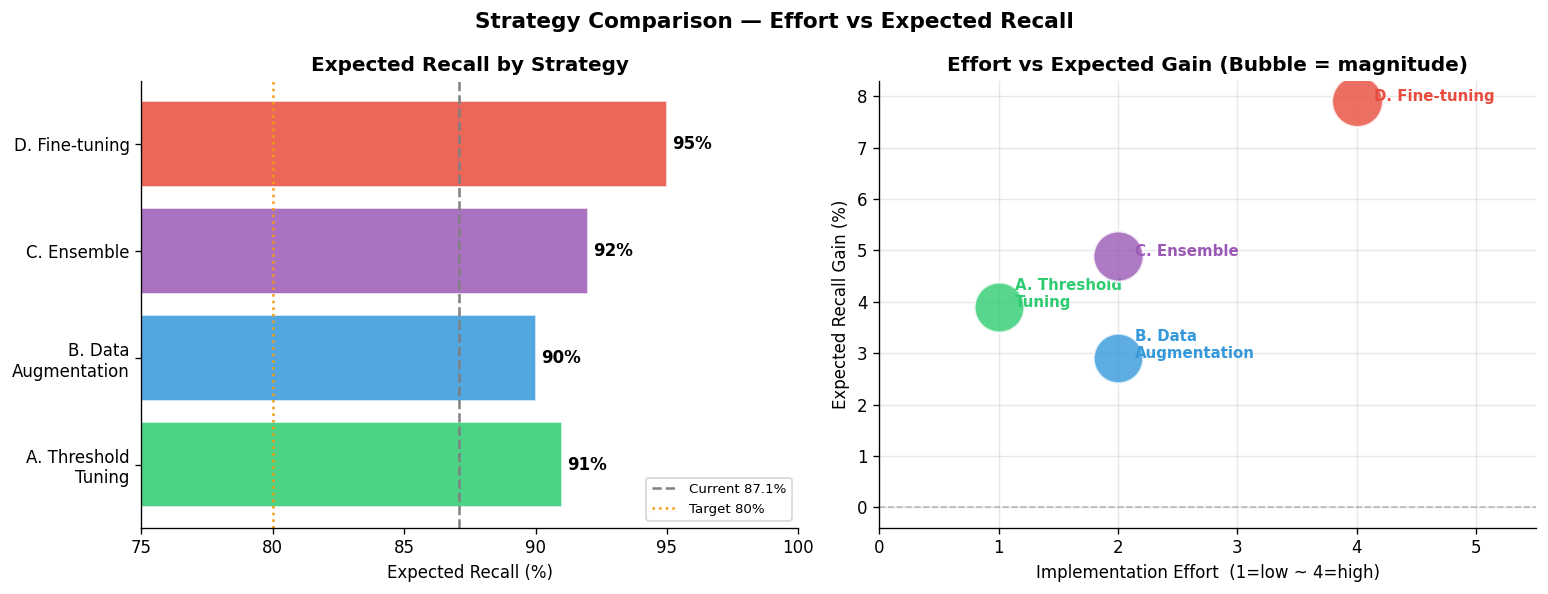

Saved: benchmark_strategy.png


In [10]:
# 전략별 기대 효과 & 비용 비교
strategies = [
    {'name': 'A. Threshold\nTuning',  'effort': 1, 'recall': 91, 'color': '#2ecc71'},
    {'name': 'B. Data\nAugmentation', 'effort': 2, 'recall': 90, 'color': '#3498db'},
    {'name': 'C. Ensemble',            'effort': 2, 'recall': 92, 'color': '#9b59b6'},
    {'name': 'D. Fine-tuning',         'effort': 4, 'recall': 95, 'color': '#e74c3c'},
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Strategy Comparison — Effort vs Expected Recall',
             fontsize=13, fontweight='bold')

# 왼쪽: 기대 Recall 막대
ax = axes[0]
names   = [s['name'] for s in strategies]
recalls = [s['recall'] for s in strategies]
colors  = [s['color'] for s in strategies]

bars = ax.barh(names, recalls, color=colors, alpha=0.85, edgecolor='white')
ax.axvline(87.1, color='grey',        linestyle='--', linewidth=1.5,
           label='Current 87.1%')
ax.axvline(80,   color=COLOR_TARGET,  linestyle=':',  linewidth=1.5,
           label='Target 80%')
ax.set_xlim(75, 100)
ax.set_xlabel('Expected Recall (%)')
ax.set_title('Expected Recall by Strategy', fontweight='bold')
ax.legend(fontsize=8)
for bar, val in zip(bars, recalls):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=10, fontweight='bold')

# 오른쪽: 노력 대비 효과 버블
ax = axes[1]
efforts = [s['effort'] for s in strategies]
gains   = [r - 87.1 for r in recalls]

for s, g, c in zip(strategies, gains, colors):
    ax.scatter(s['effort'], g, s=s['recall']*10,
               color=c, alpha=0.8, edgecolors='white', linewidth=1.5, zorder=3)
    ax.annotate(s['name'], (s['effort'], g),
                textcoords='offset points', xytext=(10, 0),
                fontsize=9, fontweight='bold', color=c)

ax.axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Implementation Effort  (1=low ~ 4=high)', fontsize=10)
ax.set_ylabel('Expected Recall Gain (%)', fontsize=10)
ax.set_title('Effort vs Expected Gain (Bubble = magnitude)', fontweight='bold')
ax.set_xlim(0, 5.5)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('benchmark_strategy.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: benchmark_strategy.png')

---
### 제안 로드맵

```
Phase 1 (즉시, 1~3일)  ← 지금 당장 시작 권장
  - 전략 A: Threshold 0.3~0.7 스윕 -> 최적값 탐색
  - 전략 B: Civitai AI 이미지 500장 + FFHQ Real 500장 추가 수집

Phase 2 (1~2주)
  - 후보 모델 3개 추가 벤치마크 (Heem2, saltacc 등)
  - 전략 C: deploy + sdxl-detector 앙상블 실험

Phase 3 (GPU 환경 확보 후, 필요 시)
  - 전략 D: ai-image-detector-deploy 파인튜닝
  - 목표: Recall 95%+ / FPR 10%- 달성
```

---

**최종 결론**

| 항목 | 내용 |
|---|---|
| 현재 최선 모델 | `haywoodsloan/ai-image-detector-deploy` (Recall 87.1%, 6/6 목표 달성) |
| 80% 달성 여부 | 이미 달성. 단, 데이터 101장 기준이므로 신뢰도 보강 필요 |
| 즉시 권장 행동 | Phase 1 — Threshold 튜닝 + 데이터 500장 추가 수집 |
| 학습 필요 여부 | Phase 1~2로 90%+ 가능성 높음. 학습은 Phase 3에서 검토 |

*woochul ver. InSIGHT — 성능 향상 전략 리포트*

---
## 8. YOLO 모델을 선정하지 않은 이유

> 수강생 다수가 YOLO 기반 객체 탐지를 경험한 만큼,  
> 왜 이 프로젝트에서 YOLO를 채택하지 않았는지 명확히 서술합니다.

---

### YOLO vs ViT — 태스크 정의부터 다르다

| 구분 | YOLO (객체 탐지) | ViT 기반 탐지기 (본 프로젝트) |
|---|---|---|
| **태스크** | 이미지 내 객체 위치(Bounding Box) + 분류 | 이미지 전체가 AI 생성인지 분류 |
| **출력** | `[x, y, w, h, class, confidence]` | `[AI 확률, Real 확률]` |
| **판단 단위** | 객체 하나하나 (부분) | 이미지 전체 (전역) |
| **학습 데이터** | 바운딩 박스 라벨 필요 | 이미지 레벨 라벨만 필요 |

**핵심:** AI 생성 이미지 탐지는 "이 이미지 전체가 진짜인가 가짜인가"를 판별하는  
**이미지 수준 이진 분류(Image-level Binary Classification)** 문제.  
YOLO는 이미지 안의 특정 객체를 찾아내는 **객체 탐지(Object Detection)** 문제에 특화되어 있어,  
**태스크 자체가 다르다.**

---

### 기술적 이유

#### 1. AI 생성 흔적은 특정 위치가 아닌 전역(Global) 패턴에 존재
```
실제 사진:   노이즈, 렌즈 왜곡, 광학 수차 등 물리적 특성이 전역에 분포
AI 생성 이미지: GAN/Diffusion 아티팩트, 주파수 패턴이 이미지 전체에 분산
               -> 어느 한 영역을 잘라서 판단하면 패턴이 희석됨
```
YOLO는 로컬 패치(local patch)를 보는 방식 -> **전역 패턴 포착에 불리**

#### 2. YOLO로 AI 탐지를 하려면 바운딩 박스 라벨이 필요
```
YOLO 학습: '어느 영역이 AI 생성인가?' -> 픽셀 단위 or 박스 단위 라벨 필요
현실:      AI 생성 이미지에 박스를 어디에 그려야 하는가? -> 정의 불가
```
이미지 전체가 AI 생성이면 박스를 이미지 전체에 그려야 하는데,  
이는 YOLO의 사용 목적과 맞지 않음.

#### 3. ViT가 이 태스크에 구조적으로 우월
```
ViT (Vision Transformer):
  - 이미지를 패치로 분할 후 Self-Attention으로 전역 관계 학습
  - GAN/Diffusion 생성 시 발생하는 전역적 일관성 패턴 포착에 최적
  - 이미지 분류(CLS 토큰)로 바로 이진 판별 출력

YOLO:
  - CSP + FPN 구조, 다양한 스케일의 로컬 특징 추출에 최적화
  - 빠른 추론 속도, 실시간 객체 탐지에 강점
  - 전역 패턴 학습은 구조적으로 ViT보다 제한적
```

---

### YOLO가 활용 가능한 경우 (참고)

YOLO가 완전히 쓸모없는 것은 아님. 다음 시나리오에서는 보조 활용 가능:

| 시나리오 | YOLO 역할 |
|---|---|
| 얼굴만 크롭해서 탐지기에 전달 | 전처리 단계 얼굴 검출 (YOLOv8-face) |
| 합성 영역이 일부인 부분 합성 탐지 | 합성 영역 Bounding Box 탐지 |
| 영상(Video)에서 인물 추적 후 판별 | 인물 트래킹 -> 프레임 추출 |

**단, 본 프로젝트(이미지 전체가 AI 생성인지 판별)에는 해당 없음.**

---

### 요약

```
YOLO  = 이미지 안 어디에 무엇이 있는가? (Where + What)
ViT   = 이 이미지 자체가 진짜인가 가짜인가? (Real or Fake)

-> 문제 정의가 다르기 때문에 YOLO는 선정하지 않음.
   YOLO를 쓰려면 태스크를 객체 탐지로 재정의해야 하며,
   그 경우 박스 라벨 생성이라는 추가 비용이 발생함.
```